<!-- # TTT Challenge
In this challenge players collect points by matching randomly selected monsters as close as possible according to various criteria
- attribute
- level
- atk
- def
- type
- border

An initial idea was to find the most "average" monster by computing the medoid of the dataset, i.e. the monster that minimizes the total distance to all other monsters. For most cases this is a pretty meaningful definition of average.
However, the medoid monster is not necessarily the best choice for TTT, since this challenge is about exactly matching. Therefore, the better approach is to find the modes of the dataset, i.e. the most common values for each category. By scoring monsters based on how many mode values they match, we can find the monsters that are most likely to score well in TTT. -->

# TTT Challenge
In this challenge players collect points by matching randomly selected monsters as close as possible according to various criteria

- attribute
- level
- atk
- def
- type
- border

An initial idea was to find the most "average" monster by computing the medoid of the dataset, i.e. the monster that minimizes the total distance to all other monsters. For most cases this is a pretty meaningful definition of average.
However, the medoid monster is not necessarily the best choice for TTT, since this challenge is about exactly matching. Therefore, the better approach is to find the modes of the dataset, i.e. the most common values for each category. 
By scoring monsters based on how many mode values they match, we can find the monsters that are most likely to score well in TTT.

## Results
The following 3 monsters have the highest TTT scores:
- Zero Gardna
- Gimmick Puppet Little Soldiers
- Goblin Decoy Squad

## Mode Calculation

In [ ]:
import os
import pandas as pd
from tqdm.notebook import tqdm

CARD_DIR = "en/" # https://github.com/db-ygoresources-com/yugioh-card-history
PARQUET_PATH = "monsters.parquet"

if os.path.exists(PARQUET_PATH):
    df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")
else:
    monsters = []
    files = [
        f for f in os.listdir(CARD_DIR)
        if f.endswith(".json")
    ]

    for file in tqdm(files, desc="parsing cards"):
        path = os.path.join(CARD_DIR, file)
        card = pd.read_json(path, typ="series")
        if card.get("type") != "monster":
            continue
        monsters.append(card)

    df = pd.DataFrame(monsters)

    df['type'] = df.apply(lambda r: r.properties[0], axis=1)
    df['border'] = df['properties'].apply(lambda p:
        "Effect" if p[1] == "Tuner" or p[1] == "Toon" or p[1] == "Union" or p[1] == "Gemini" or p[1] == "Spirit" or p[1] == "Flip"
            else p[1] if "Pendulum" not in p 
            else f'Pendulum/{p[3]}' if p[2] == "Tuner" or p[2] == "Toon" or p[2] == "Union" or p[2] == "Gemini" or p[2] == "Spirit" or p[2] == "Flip"
            else f'Pendulum/{p[2]}' if p[2] == "Effect" or p[2] == "Normal" 
            else f'Pendulum/{p[1]}')
    df.rename(columns={'localizedAttribute': 'attribute'}, inplace=True)

    print(f'Saving as {PARQUET_PATH}')
    df.to_parquet(PARQUET_PATH, engine="pyarrow")


df = df[['name', 'attribute', 'level', 'atk', 'def', 'type', 'border']]

def top_n_modes_df(df, n=3):
    top_modes = {}
    for col in df.columns:
        top_modes[col] = df[col].value_counts().head(n).index.tolist()
        if len(top_modes[col]) < n:
            top_modes[col] += [None] * (n - len(top_modes[col]))
    return pd.DataFrame(top_modes)

mode = top_n_modes_df(df.drop('name', axis=1), n=5)
print(mode)


parsing cards:   0%|          | 0/13471 [00:00<?, ?it/s]

Saving as monsters.parquet
  attribute  level   atk     def         type   border
0      DARK    4.0     0     0.0      Warrior   Effect
1     EARTH    3.0  1000  1000.0      Machine      Xyz
2     LIGHT    8.0  1500  2000.0        Fiend   Fusion
3     WATER    2.0  1800  1200.0       Dragon   Normal
4      WIND    1.0  2000  1500.0  Spellcaster  Synchro


In [ ]:

weights = [round(1.0/i, 5) for i in range(1, mode.shape[0]+1)]
features = df.drop('name', axis=1).columns.tolist()

df['score'] = 0
for rank_idx, mode_row in mode.iterrows():
    match_matrix = df[features] == mode_row[features]     
    df['score'] += match_matrix.dot([weights[rank_idx]] * len(features))

# Top 10 scoring cards
print(df.sort_values('score', ascending=False).head(10))

                                name attribute  level   atk  def     type  \
7802                     Zero Gardna     EARTH    4.0     0  0.0  Warrior   
4839  Gimmick Puppet Little Soldiers      DARK    4.0     0  0.0  Machine   
7422              Goblin Decoy Squad      DARK    4.0  1000  0.0  Warrior   
8718                Kagemucha Knight      DARK    3.0     0  0.0  Warrior   
1760            Cipher Mirror Knight     LIGHT    4.0     0  0.0  Warrior   
7914      Ogre of the Scarlet Sorrow      DARK    4.0     0  0.0    Fiend   
7126                Phantom of Chaos      DARK    4.0     0  0.0    Fiend   
1871                  Envoy of Chaos      DARK    4.0  1500  0.0  Warrior   
3869                     Astraltopia     LIGHT    4.0     0  0.0  Warrior   
4404                   Photon Jumper     LIGHT    4.0     0  0.0  Warrior   

      border    score  
7802  Effect  5.50000  
4839  Effect  5.50000  
7422  Effect  5.50000  
8718  Effect  5.50000  
1760  Effect  5.33333  
7914  Ef

In [59]:
df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")
df = df[['id', 'name', 'attribute', 'level', 'atk', 'def', 'type', 'border']]

## Medoid Calculation

In [60]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(sparse_output=False)
categorical_features = ['attribute', 'type', 'border']
encoded_features = encoder.fit_transform(df[categorical_features])

numeric_features = ['level', 'atk', 'def']
num_vectors = df[numeric_features].fillna(-1).to_numpy(dtype=float)

X = np.hstack([encoded_features, num_vectors])

In [61]:
def euclidean_nan(u, v):
    mask = ~np.isnan(u) & ~np.isnan(v)
    if np.sum(mask) == 0:
        return np.inf
    return np.linalg.norm(u[mask] - v[mask])

In [62]:
from scipy.spatial.distance import cdist

print(X.shape)
n = X.shape[0]

dist_matrix = np.zeros((n, n))

chunk_size = 100
for start in tqdm(range(0, n, chunk_size), desc="Computing dist matrix"):
    end = min(start + chunk_size, n)
    dist_matrix[start:end] = cdist(X[start:end], X, metric='euclidean')  

(8751, 48)


Computing dist matrix:   0%|          | 0/88 [00:00<?, ?it/s]

In [63]:
sum_distances = dist_matrix.sum(axis=1)
medoid_index = np.argmin(sum_distances)
medoid_monster = df.iloc[medoid_index]
print(medoid_monster)

id                                        18790
name         Gazelle the King of Mythical Claws
attribute                                 EARTH
level                                       4.0
atk                                        1500
def                                      1200.0
type                                      Beast
border                                   Effect
Name: 4502, dtype: object


In [64]:
import umap

reducer = umap.UMAP(
    n_neighbors=16,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=305867
)

X_umap = reducer.fit_transform(X)

df["umap_x"] = X_umap[:, 0]
df["umap_y"] = X_umap[:, 1]

c:\Users\Julian\Documents\ygo-db\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Julian\Documents\ygo-db\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


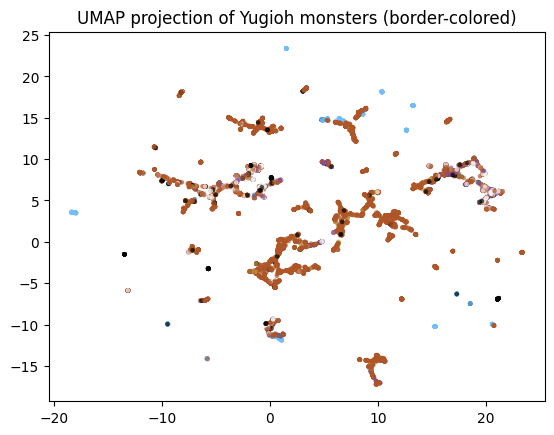

In [98]:
import matplotlib.pyplot as plt

border_colors = {
    "Xyz": "#010304",
    "Link": "#70beff",
    "Ritual": "#54669b",
    "Effect": "#af5628",
    "Normal": "#c09542",
    "Fusion": "#874a9b",
    "Synchro": "#f6f6f6",
    "Pendulum/Effect": "#af5628",
    "Pendulum/Xyz": "#010304",
    "Pendulum/Synchro": "#f6f6f6",
    "Pendulum/Fusion" : "#874a9b",
    "Pendulum/Normal": "#c09542",
    "Pendulum/Ritual": "#54669b"
}

df["border_color"] = df["border"].map(border_colors)

plt.scatter(
    df["umap_x"],
    df["umap_y"],
    c=df["border_color"],
    s=11,
    alpha=0.7,
    edgecolors="none"
)
plt.title("UMAP projection of Yugioh monsters (border-colored)")
plt.show()

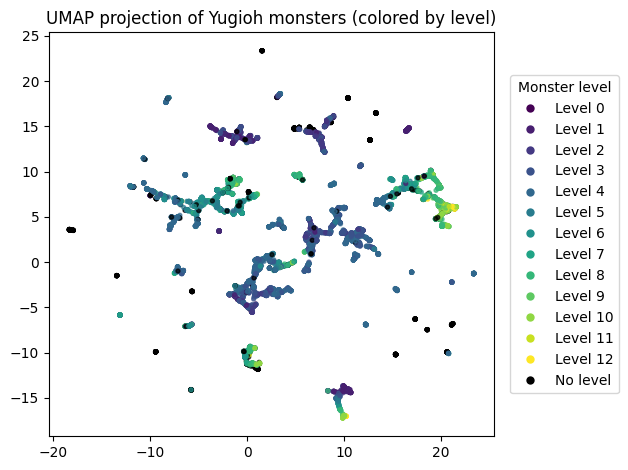

In [99]:
from matplotlib.lines import Line2D

levels = df["level"].to_numpy()
has_level = ~np.isnan(levels)

unique_levels = np.sort(np.unique(levels[has_level])).astype(int)

cmap = plt.cm.viridis
level_to_color = {
    lvl: cmap(i / max(len(unique_levels) - 1, 1))
    for i, lvl in enumerate(unique_levels)
}

colors = np.zeros((len(df), 4))
for lvl, col in level_to_color.items():
    colors[levels == lvl] = col

colors[~has_level] = (0, 0, 0, 1)

plt.scatter(
    df["umap_x"],
    df["umap_y"],
    c=colors,
    s=8,
    alpha=0.7
)
plt.title("UMAP projection of Yugioh monsters (colored by level)")

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        label=f"Level {lvl}",
        markerfacecolor=level_to_color[lvl],
        markeredgecolor='none',
        markersize=6
    )
    for lvl in unique_levels
]

legend_elements.append(
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        label="No level",
        markerfacecolor='black',
        markeredgecolor='none',
        markersize=6
    )
)

plt.legend(
    handles=legend_elements,
    title="Monster level",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True
)

plt.tight_layout()
plt.show()

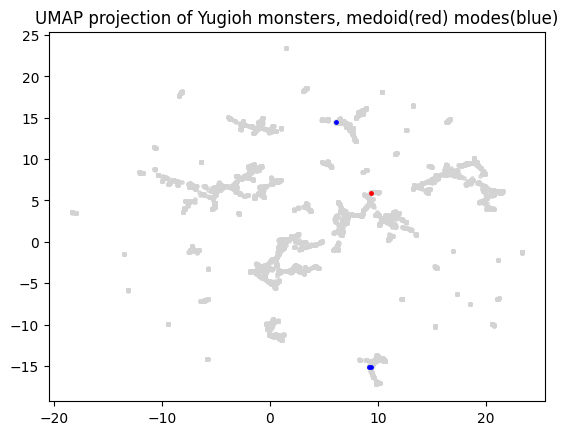

In [95]:
df['highlight_color'] = 'lightgray'
df.loc[medoid_index, 'color'] = 'red' 
      
plt.scatter(X_umap[:, 0], X_umap[:, 1], color='lightgray',s=6, alpha=0.7)
plt.scatter(X_umap[medoid_index, 0], X_umap[medoid_index, 1], color='red', s=6)
plt.scatter(X_umap[7802, 0], X_umap[7802, 1], color='blue', s=6)
plt.scatter(X_umap[4839, 0], X_umap[4839, 1], color='blue', s=6)
plt.scatter(X_umap[7422, 0], X_umap[7422, 1], color='blue', s=6)
plt.title("UMAP projection of Yugioh monsters, medoid(red) modes(blue)")
plt.show()